In [46]:
# Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
# Carga desde un archivo .csv sin indice
br = pd.read_csv('Base_resumen.csv', header=5) 

In [48]:
# Verificamos información del DataFrame
br.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Año                           4 non-null      str    
 1   Mes                           42 non-null     str    
 2   Leads                         39 non-null     str    
 3   Efectivos                     39 non-null     str    
 4   Ventas Reportadas             39 non-null     float64
 5   Obj Ventas                    30 non-null     float64
 6   Ventas Real                   39 non-null     float64
 7   % CAL                         30 non-null     str    
 8   Obj Conversion                30 non-null     str    
 9   Conversion                    39 non-null     str    
 10  % CAL                         30 non-null     str    
 11  Obj UN                        7 non-null      str    
 12  UN                            6 non-null      str    
 13  %  CAL            

In [49]:
# Limpieza antes de empezar
br["Año"] = br["Año"].replace("", pd.NA).ffill()
br = br.iloc[:30]
br = br.iloc[:, :34]
br.columns = br.columns.str.strip()

In [ ]:
# Correción tipos de datos
cols_int = ["Año", "Leads", "Efectivos", "Ventas Reportadas", "Obj Ventas", "Ventas Real", "Obj SDC", "SDC", "Autorizadas", "Formalizado", "Contado", "Credito",
            "Obj PDM", "PDM", "Obj Marca", "Flotillas"]

br[cols_int] = br[cols_int].replace(",", "", regex=True).astype("Int64")

In [54]:
# Verificar otra vez
br.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Año                           30 non-null     Int64  
 1   Mes                           30 non-null     str    
 2   Leads                         30 non-null     Int64  
 3   Efectivos                     30 non-null     Int64  
 4   Ventas Reportadas             30 non-null     Int64  
 5   Obj Ventas                    30 non-null     Int64  
 6   Ventas Real                   30 non-null     Int64  
 7   % CAL                         30 non-null     float64
 8   Obj Conversion                30 non-null     str    
 9   Conversion                    30 non-null     str    
 10  % CAL                         30 non-null     float64
 11  Obj UN                        7 non-null      str    
 12  UN                            6 non-null      str    
 13  %  CAL            

In [55]:
# Calculamos el numero total de la población "n"
br['Leads'].info()
n=30

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Leads
Non-Null Count  Dtype
--------------  -----
30 non-null     Int64
dtypes: Int64(1)
memory usage: 402.0 bytes


In [56]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=br['Leads'].max()
Min=br['Leads'].min()
Limites= [Min, Max]
Limites

[np.int64(178), np.int64(1973)]

In [57]:
# Calculamos el rango R
R=Max-Min
R

np.int64(1795)

In [58]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.904042565669279)

In [59]:
# Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(304.02897337453726)

In [61]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(178, 1973, 6).astype(int)
intervalos

array([ 178,  537,  896, 1255, 1614, 1973])

In [62]:
# Creamos las categorías
categorias = ["Leads bajos (178-537)", "Leads moderados (537-896)", "Leads buenos (896-1255)",
              "Leads altos (1255-1614)", "Leads muy altos (1614-1973)"]

In [63]:
# Finalmente creamos las categorías en la columna numérica
br['Leads']=pd.cut(x= br['Leads'], bins=intervalos, labels= categorias)
br['Leads']

0       Leads moderados (537-896)
1                             NaN
2           Leads bajos (178-537)
3           Leads bajos (178-537)
4         Leads buenos (896-1255)
5         Leads buenos (896-1255)
6         Leads altos (1255-1614)
7         Leads altos (1255-1614)
8     Leads muy altos (1614-1973)
9         Leads altos (1255-1614)
10        Leads altos (1255-1614)
11        Leads buenos (896-1255)
12      Leads moderados (537-896)
13        Leads buenos (896-1255)
14        Leads buenos (896-1255)
15      Leads moderados (537-896)
16        Leads buenos (896-1255)
17        Leads altos (1255-1614)
18        Leads altos (1255-1614)
19        Leads buenos (896-1255)
20        Leads buenos (896-1255)
21        Leads buenos (896-1255)
22        Leads altos (1255-1614)
23        Leads altos (1255-1614)
24        Leads buenos (896-1255)
25    Leads muy altos (1614-1973)
26        Leads altos (1255-1614)
27        Leads buenos (896-1255)
28        Leads altos (1255-1614)
29          Le

In [64]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq = br['Leads'].value_counts().reset_index()
Tabla_freq

,Leads,count
0,Leads buenos (896-1255),11
1,Leads altos (1255-1614),10
2,Leads bajos (178-537),3
3,Leads moderados (537-896),3
4,Leads muy altos (1614-1973),2


In [65]:
#Ajusto el indice de mi dataframe
Tabla_freq_i = Tabla_freq.set_index('Leads')
Tabla_freq_i

,count
Leads,
Leads buenos (896-1255),11
Leads altos (1255-1614),10
Leads bajos (178-537),3
Leads moderados (537-896),3
Leads muy altos (1614-1973),2


Text(0, 0.5, 'Frecuencia')

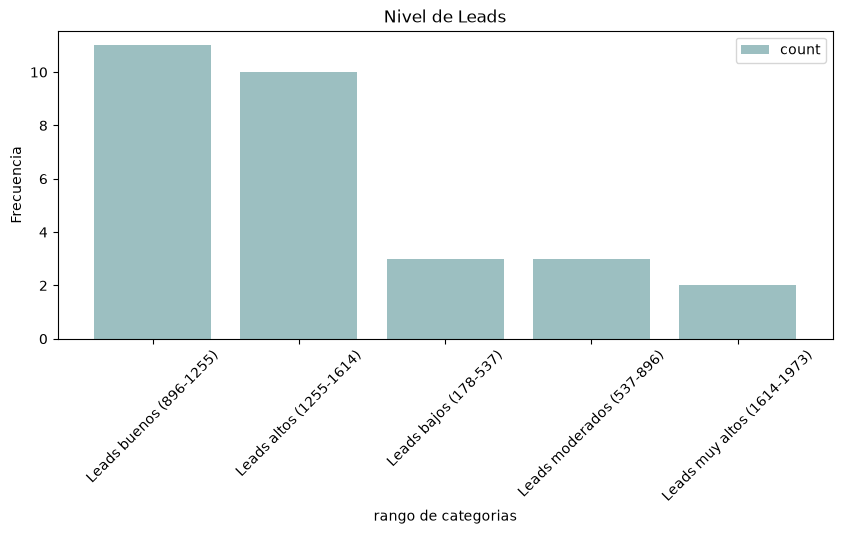

In [66]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "#9CBFC1", rot=45)
plt.title('Nivel de Leads')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [67]:
# Calculamos el numero total de la población "n"
br['Efectivos'].info()
n=30

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Efectivos
Non-Null Count  Dtype
--------------  -----
30 non-null     Int64
dtypes: Int64(1)
memory usage: 402.0 bytes


In [68]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max1=br['Efectivos'].max()
Min1=br['Efectivos'].min()
Limites1= [Min1, Max1]
Limites1

[np.int64(128), np.int64(1040)]

In [69]:
# Calculamos el rango R
R1=Max1-Min1
R1

np.int64(912)

In [70]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni1= 1+3.32*np.log10(n)
ni1

np.float64(5.904042565669279)

In [71]:
# Calculamos el Ancho del Intervalo "i"
i1=R1/ni1
i1

np.float64(154.47043104043343)

In [72]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos1=np.linspace(128, 1040, 6).astype(int)
intervalos1

array([ 128,  310,  492,  675,  857, 1040])

In [73]:
# Creamos las categorías
categorias1 = ["Efectivos bajos (128-310)", "Efectivos moderados (310-492)", "Efectivos buenos (492-675)",
               "Efectivos altos (675-857)", "Efectivos muy altos (857-1040)"]

In [74]:
# Finalmente creamos las categorías en la columna numérica
br['Efectivos']=pd.cut(x= br['Efectivos'], bins=intervalos1, labels= categorias1)
br['Efectivos']

0      Efectivos moderados (310-492)
1                                NaN
2          Efectivos bajos (128-310)
3          Efectivos bajos (128-310)
4         Efectivos buenos (492-675)
5         Efectivos buenos (492-675)
6         Efectivos buenos (492-675)
7         Efectivos buenos (492-675)
8          Efectivos altos (675-857)
9     Efectivos muy altos (857-1040)
10    Efectivos muy altos (857-1040)
11         Efectivos altos (675-857)
12     Efectivos moderados (310-492)
13         Efectivos altos (675-857)
14    Efectivos muy altos (857-1040)
15         Efectivos altos (675-857)
16         Efectivos altos (675-857)
17    Efectivos muy altos (857-1040)
18        Efectivos buenos (492-675)
19        Efectivos buenos (492-675)
20         Efectivos altos (675-857)
21         Efectivos altos (675-857)
22         Efectivos altos (675-857)
23         Efectivos altos (675-857)
24         Efectivos altos (675-857)
25    Efectivos muy altos (857-1040)
26         Efectivos altos (675-857)
2

In [75]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq1 = br['Efectivos'].value_counts().reset_index()
Tabla_freq1

,Efectivos,count
0,Efectivos altos (675-857),13
1,Efectivos buenos (492-675),6
2,Efectivos muy altos (857-1040),5
3,Efectivos bajos (128-310),3
4,Efectivos moderados (310-492),2


In [77]:
#Ajusto el indice de mi dataframe
Tabla_freq_i1 = Tabla_freq1.set_index('Efectivos')
Tabla_freq_i1

,count
Efectivos,
Efectivos altos (675-857),13
Efectivos buenos (492-675),6
Efectivos muy altos (857-1040),5
Efectivos bajos (128-310),3
Efectivos moderados (310-492),2


Text(0, 0.5, 'Frecuencia')

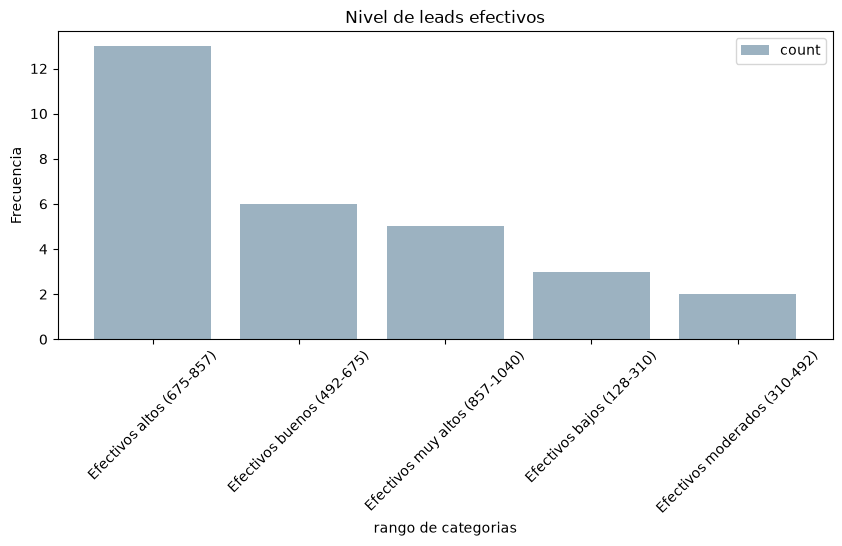

In [78]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i1.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "#9CB2C1", rot=45)
plt.title('Nivel de leads efectivos')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [80]:
# Calculamos el numero total de la población "n"
br['Ventas Reportadas'].info()
n=30

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Ventas Reportadas
Non-Null Count  Dtype
--------------  -----
30 non-null     Int64
dtypes: Int64(1)
memory usage: 402.0 bytes


In [81]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max2=br['Ventas Reportadas'].max()
Min2=br['Ventas Reportadas'].min()
Limites2= [Min2, Max2]
Limites2

[np.int64(6), np.int64(41)]

In [82]:
# Calculamos el rango R
R2=Max2-Min2
R2

np.int64(35)

In [83]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni2= 1+3.32*np.log10(n)
ni2

np.float64(5.904042565669279)

In [84]:
# Calculamos el Ancho del Intervalo "i"
i2=R2/ni2
i2

np.float64(5.928141542121897)

In [85]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos2=np.linspace(6, 41, 6).astype(int)
intervalos2

array([ 6, 13, 20, 27, 34, 41])

In [86]:
# Creamos las categorías
categorias2 = ["Ventas bajas (6-13)", "Ventas moderadas (13-20)", "Ventas buenas (20-27)",
               "Ventas altas (27-34)", "Ventas muy altas (34-41)"]

In [87]:
# Finalmente creamos las categorías en la columna numérica
br['Ventas Reportadas']=pd.cut(x= br['Ventas Reportadas'], bins=intervalos2, labels= categorias2)
br['Ventas Reportadas']

0          Ventas bajas (6-13)
1          Ventas bajas (6-13)
2          Ventas bajas (6-13)
3          Ventas bajas (6-13)
4                          NaN
5        Ventas buenas (20-27)
6     Ventas moderadas (13-20)
7     Ventas moderadas (13-20)
8        Ventas buenas (20-27)
9        Ventas buenas (20-27)
10        Ventas altas (27-34)
11       Ventas buenas (20-27)
12    Ventas moderadas (13-20)
13        Ventas altas (27-34)
14        Ventas altas (27-34)
15        Ventas altas (27-34)
16    Ventas muy altas (34-41)
17    Ventas muy altas (34-41)
18       Ventas buenas (20-27)
19    Ventas muy altas (34-41)
20    Ventas muy altas (34-41)
21    Ventas muy altas (34-41)
22        Ventas altas (27-34)
23    Ventas muy altas (34-41)
24        Ventas altas (27-34)
25    Ventas muy altas (34-41)
26    Ventas muy altas (34-41)
27    Ventas muy altas (34-41)
28    Ventas muy altas (34-41)
29        Ventas altas (27-34)
Name: Ventas Reportadas, dtype: category
Categories (5, str): ['Ventas

In [88]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq2 = br['Ventas Reportadas'].value_counts().reset_index()
Tabla_freq2

,Ventas Reportadas,count
0,Ventas muy altas (34-41),10
1,Ventas altas (27-34),7
2,Ventas buenas (20-27),5
3,Ventas bajas (6-13),4
4,Ventas moderadas (13-20),3


In [89]:
#Ajusto el indice de mi dataframe
Tabla_freq_i2 = Tabla_freq2.set_index('Ventas Reportadas')
Tabla_freq_i2

,count
Ventas Reportadas,
Ventas muy altas (34-41),10
Ventas altas (27-34),7
Ventas buenas (20-27),5
Ventas bajas (6-13),4
Ventas moderadas (13-20),3


Text(0, 0.5, 'Frecuencia')

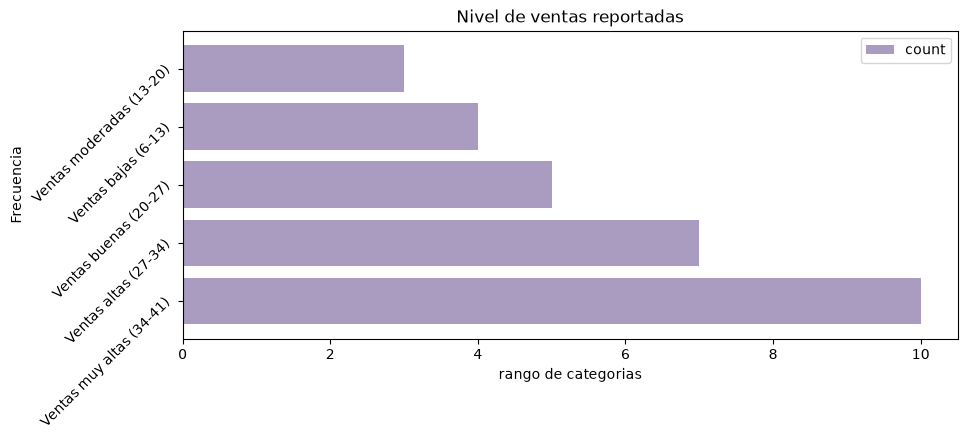

In [90]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i2.plot(kind = 'barh', width=0.8, figsize=(10,4), color= "#AA9CC1", rot=45)
plt.title('Nivel de ventas reportadas')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [92]:
# Calculamos el numero total de la población "n"
br['Ventas Real'].info()
n=30

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Ventas Real
Non-Null Count  Dtype
--------------  -----
30 non-null     Int64
dtypes: Int64(1)
memory usage: 402.0 bytes


In [93]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max3=br['Ventas Real'].max()
Min3=br['Ventas Real'].min()
Limites3= [Min3, Max3]
Limites3

[np.int64(6), np.int64(42)]

In [94]:
# Calculamos el rango R
R3=Max3-Min3
R3

np.int64(36)

In [95]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni3= 1+3.32*np.log10(n)
ni3

np.float64(5.904042565669279)

In [96]:
# Calculamos el Ancho del Intervalo "i"
i3=R3/ni3
i3

np.float64(6.097517014753951)

In [97]:
#Categorización de variables
#Declaramos 6 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos3=np.linspace(6, 42, 7).astype(int)
intervalos3

array([ 6, 12, 18, 24, 30, 36, 42])

In [98]:
# Creamos las categorías
categorias3 = ["Ventas muy bajas (6-12)", "Ventas bajas (12-18)", "Ventas moderadas (18-24)",
               "Ventas buenas (24-30)", "Ventas altas (30-36)", "Ventas muy altas (36-42)"]

In [100]:
# Finalmente creamos las categorías en la columna numérica
br['Ventas Real']=pd.cut(x= br['Ventas Real'], bins=intervalos3, labels= categorias3)
br['Ventas Real']

0      Ventas muy bajas (6-12)
1      Ventas muy bajas (6-12)
2      Ventas muy bajas (6-12)
3         Ventas bajas (12-18)
4                          NaN
5     Ventas moderadas (18-24)
6         Ventas bajas (12-18)
7         Ventas bajas (12-18)
8     Ventas moderadas (18-24)
9     Ventas moderadas (18-24)
10        Ventas altas (30-36)
11       Ventas buenas (24-30)
12    Ventas moderadas (18-24)
13       Ventas buenas (24-30)
14       Ventas buenas (24-30)
15        Ventas altas (30-36)
16    Ventas muy altas (36-42)
17        Ventas altas (30-36)
18       Ventas buenas (24-30)
19    Ventas muy altas (36-42)
20    Ventas muy altas (36-42)
21    Ventas muy altas (36-42)
22        Ventas altas (30-36)
23    Ventas muy altas (36-42)
24       Ventas buenas (24-30)
25    Ventas muy altas (36-42)
26    Ventas muy altas (36-42)
27        Ventas altas (30-36)
28    Ventas muy altas (36-42)
29        Ventas altas (30-36)
Name: Ventas Real, dtype: category
Categories (6, str): ['Ventas muy b

In [101]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq3 = br['Ventas Real'].value_counts().reset_index()
Tabla_freq3

,Ventas Real,count
0,Ventas muy altas (36-42),8
1,Ventas altas (30-36),6
2,Ventas buenas (24-30),5
3,Ventas moderadas (18-24),4
4,Ventas muy bajas (6-12),3
5,Ventas bajas (12-18),3


In [102]:
#Ajusto el indice de mi dataframe
Tabla_freq_i3 = Tabla_freq3.set_index('Ventas Real')
Tabla_freq_i3

,count
Ventas Real,
Ventas muy altas (36-42),8
Ventas altas (30-36),6
Ventas buenas (24-30),5
Ventas moderadas (18-24),4
Ventas muy bajas (6-12),3
Ventas bajas (12-18),3


Text(0, 0.5, 'Frecuencia')

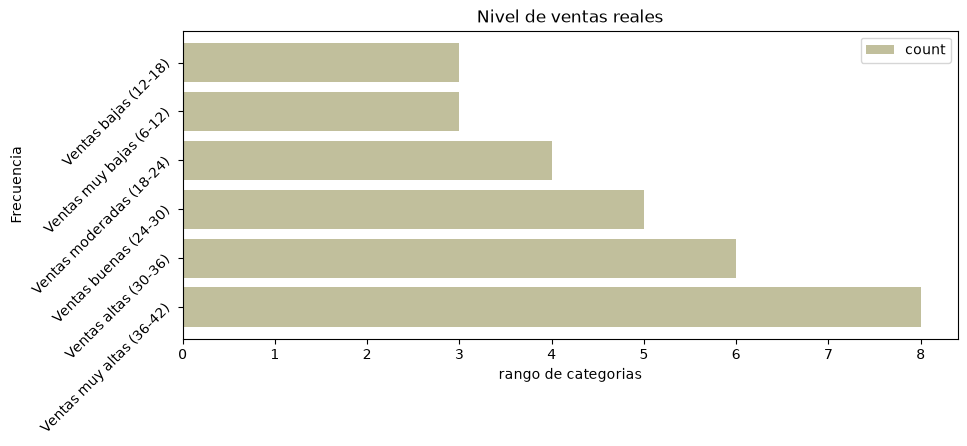

In [103]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i3.plot(kind = 'barh', width=0.8, figsize=(10,4), color= "#C1BF9C", rot=45)
plt.title('Nivel de ventas reales')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')